In [11]:
import torch as th
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np

In [63]:
with open ('data/funky.csv', 'rb') as f:
  all_data = np.loadtxt(f, delimiter=",", dtype="float32")

data = dict()
data["x"] = all_data[:, 0]
data["y"] = all_data[:, 1]

nb_samples = data["x"].shape[0]
indices = np.random.permutation(nb_samples)
data["x"] = data["x"][indices]
data["y"] = data["y"][indices]

data["x"] = (data["x"] - np.mean(data["x"], axis=0)) / np.std(data["x"], axis=0)
data["y"] = (data["y"] - np.mean(data["y"])) / np.std(data["y"])

original_x = data["x"].copy()

In [49]:
# Pomocna funkcija koja od niza trening primera pravi feature matricu (m X n)
def create_feature_matrix(x, nb_features):
  tmp_features = []
  for deg in range(1, nb_features + 1):
    tmp_features.append(np.power(x, deg))
  return np.column_stack(tmp_features)

In [77]:
def make_features(nb_features):
    print("\n---------------------------")
    print(f"Broj feature-a: {nb_features}")

    x_feat = create_feature_matrix(original_x, nb_features)

    print("Originalne vrednosti (prve 3):")
    print(original_x[:3])
    print("Feature matrica (prva 3 reda):")
    print(x_feat[:3, :])

    x_tensor = th.tensor(x_feat, dtype=th.float32)
    y_tensor = th.tensor(data["y"], dtype=th.float32)

    plt.scatter(x_feat[:, 0], y_tensor)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title(f"Features: {nb_features}")
    plt.show()

    return x_tensor, y_tensor

In [75]:
#%%time

learning_rate = 0.001
nb_epochs = 1000
lmbd = 0.01

# Model / parametri - linearna regresija.
class LinearModel(th.nn.Module):
    def __init__(self, num_features):
        super().__init__()

        self.linear_layer = th.nn.Linear(in_features=num_features, out_features=1)

    def forward(self, x):
        return self.linear_layer(x)

    def compute_l1_loss(self, lmbd):
        params = []

        for p in self.parameters():
            params.append(p.view(-1))

        w = th.cat(params)

        return lmbd * th.abs(w).sum()

    def compute_l2_loss(self, lmbd):
        params = []

        for p in self.parameters():
            params.append(p.view(-1))

        w = th.cat(params)

        return lmbd * th.pow(w, 2).sum()

In [82]:
def train_model(x, y, nb_features):
    model = LinearModel(nb_features)

    loss_fn = th.nn.MSELoss()
    optimizer = th.optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(nb_epochs):
        model.train()

        # forward (batch!)
        y_pred = model(x).squeeze()

        loss = loss_fn(y_pred, y)
        loss += model.compute_l2_loss(lmbd)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # opcioni log
        # if (epoch + 1) % 200 == 0:
        #     print(f"Epoch {epoch+1}: loss = {loss.item():.5f}")
    final_loss = loss_fn(model(x).squeeze(), y).item()
    print(f"Finalni loss: {final_loss:.5f}")

    return model, final_loss

In [66]:
def plot_result(model, nb_features):
    xs = np.linspace(-2, 2, 100, dtype="float32")
    xs_feat = create_feature_matrix(xs, nb_features)

    model.eval()
    with th.inference_mode():
        ys = model(th.tensor(xs_feat)).squeeze()

    plt.plot(xs, ys, color="g")
    plt.scatter(original_x, data["y"])

    plt.xlabel("X")
    plt.ylabel("Y")
    plt.xlim([-3, 3])
    plt.ylim([-3, 3])
    plt.title(f"Model sa {nb_features} feature-a")

    plt.show()


---------------------------
Broj feature-a: 1
Originalne vrednosti (prve 3):
[-1.1262795 -1.2460359 -1.0014232]
Feature matrica (prva 3 reda):
[[-1.1262795]
 [-1.2460359]
 [-1.0014232]]


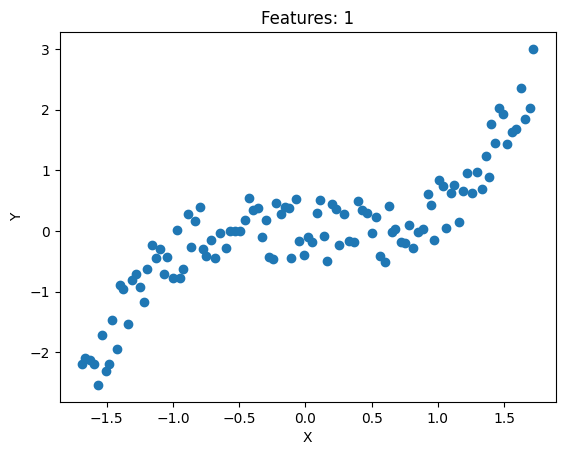

Finalni loss: 0.46790


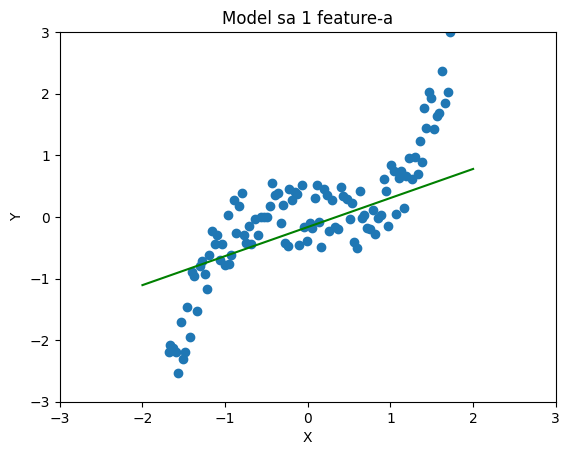


---------------------------
Broj feature-a: 2
Originalne vrednosti (prve 3):
[-1.1262795 -1.2460359 -1.0014232]
Feature matrica (prva 3 reda):
[[-1.1262795  1.2685055]
 [-1.2460359  1.5526055]
 [-1.0014232  1.0028485]]


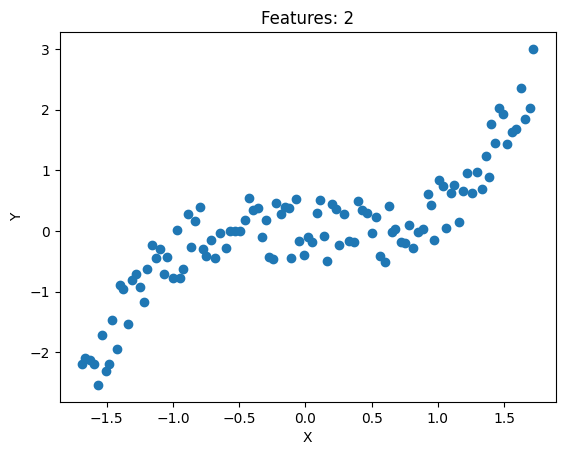

Finalni loss: 0.44853


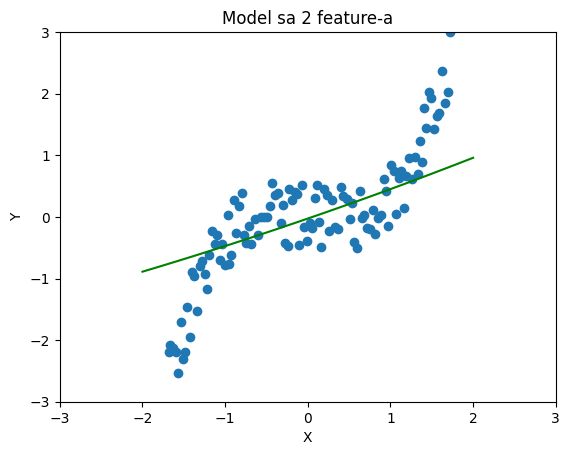


---------------------------
Broj feature-a: 3
Originalne vrednosti (prve 3):
[-1.1262795 -1.2460359 -1.0014232]
Feature matrica (prva 3 reda):
[[-1.1262795  1.2685055 -1.4286916]
 [-1.2460359  1.5526055 -1.9346023]
 [-1.0014232  1.0028485 -1.0042758]]


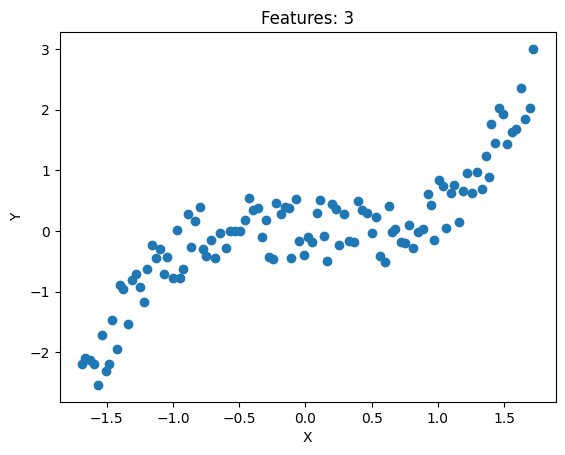

Finalni loss: 0.11316


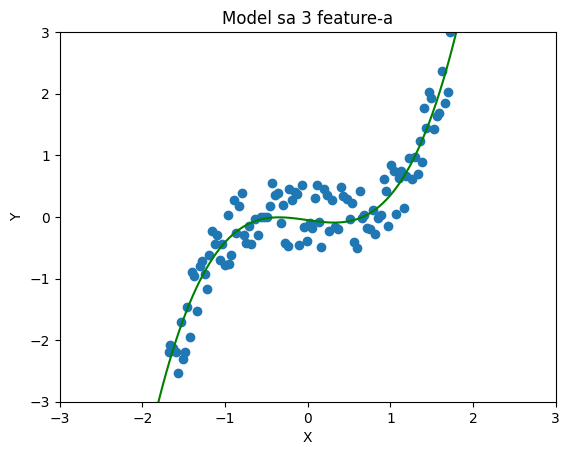


---------------------------
Broj feature-a: 4
Originalne vrednosti (prve 3):
[-1.1262795 -1.2460359 -1.0014232]
Feature matrica (prva 3 reda):
[[-1.1262795  1.2685055 -1.4286916  1.6091061]
 [-1.2460359  1.5526055 -1.9346023  2.410584 ]
 [-1.0014232  1.0028485 -1.0042758  1.0057051]]


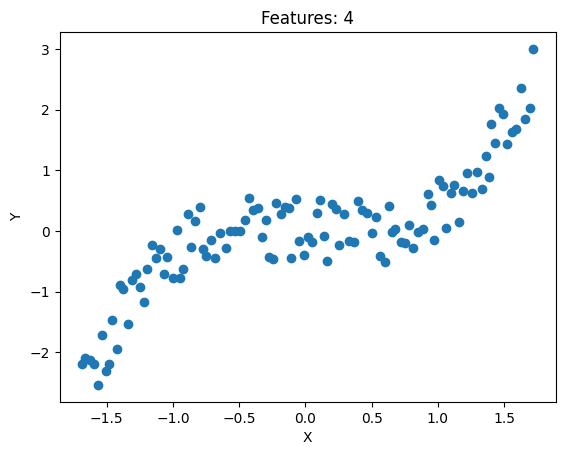

Finalni loss: 0.25837


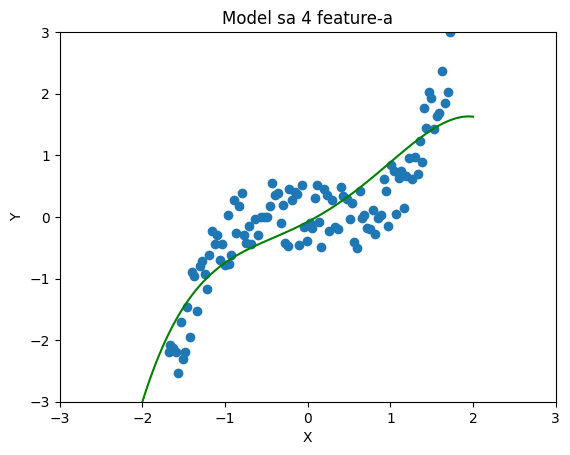


---------------------------
Broj feature-a: 5
Originalne vrednosti (prve 3):
[-1.1262795 -1.2460359 -1.0014232]
Feature matrica (prva 3 reda):
[[-1.1262795  1.2685055 -1.4286916  1.6091061 -1.8123032]
 [-1.2460359  1.5526055 -1.9346023  2.410584  -3.0036743]
 [-1.0014232  1.0028485 -1.0042758  1.0057051 -1.0071365]]


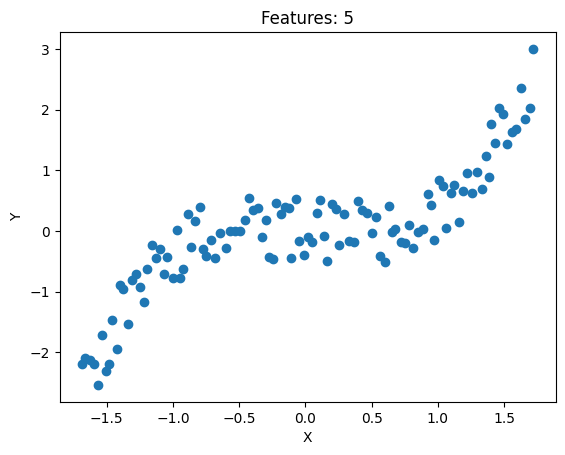

Finalni loss: 0.11882


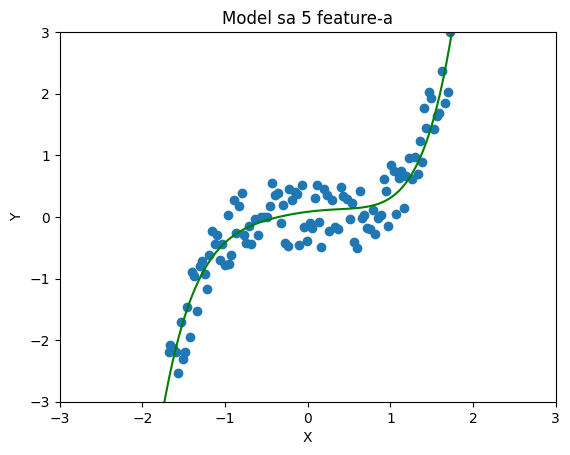


---------------------------
Broj feature-a: 6
Originalne vrednosti (prve 3):
[-1.1262795 -1.2460359 -1.0014232]
Feature matrica (prva 3 reda):
[[-1.1262795  1.2685055 -1.4286916  1.6091061 -1.8123032  2.0411599]
 [-1.2460359  1.5526055 -1.9346023  2.410584  -3.0036743  3.742686 ]
 [-1.0014232  1.0028485 -1.0042758  1.0057051 -1.0071365  1.0085698]]


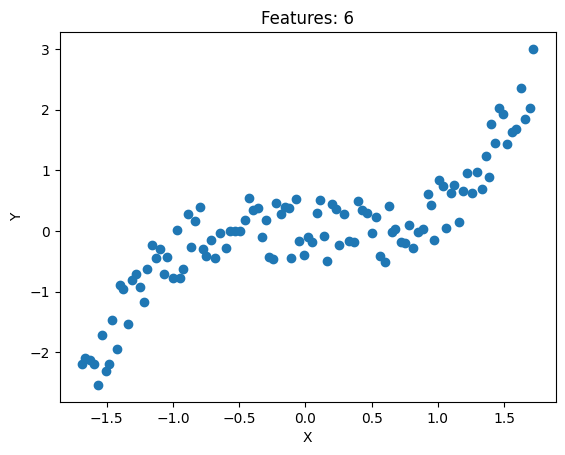

Finalni loss: 0.11603


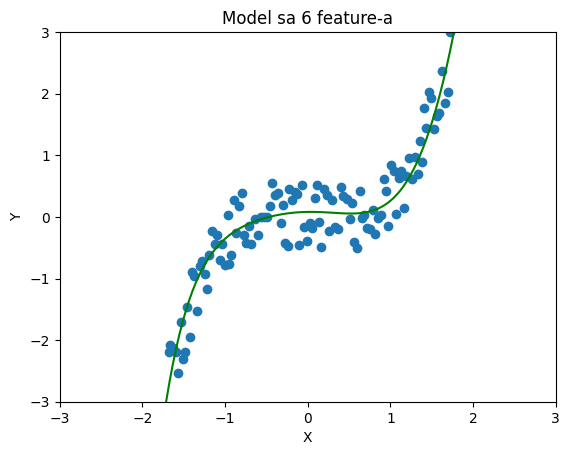

In [85]:
degrees = []
losses = []
for nb_features in range(1, 7):
    x, y = make_features(nb_features)
    model, final_loss = train_model(x, y, nb_features)
    plot_result(model, nb_features)
    degrees.append(nb_features)
    losses.append(final_loss)

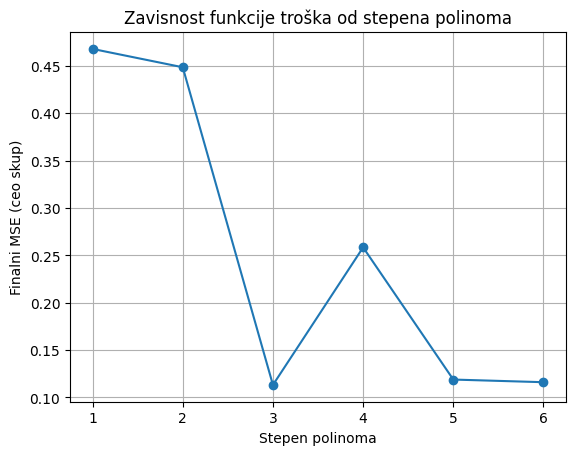

In [86]:
plt.plot(degrees, losses, marker='o')
plt.xlabel("Stepen polinoma")
plt.ylabel("Finalni MSE (ceo skup)")
plt.title("Zavisnost funkcije troška od stepena polinoma")
plt.grid()
plt.show()

Primecuje se da su polinomi stepena 1 i 2 vrlo kruti, zbog cega i imaju najveci MSE. Generalno vazi da veci stepeni omogucavaju i manji nivo greske. Zanimljiva stvar je sto MSE vrednosti mogu znatno da variraju u zavisnosti od permutacije podataka koju model dobije. Na primer, u jednom pokretanju je polinom stepena 3 imao najmanji MSE od svih drugih, dok je u drugom nivo greske relativno ravnomerno opadao.